# **Lab 01 - Introduction to Python, Gymnasium and Formulating RL Problem**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Getting familiar with Gymnasium

In [3]:
# import Gymnasium library and alias as gym
import gymnasium as gym

In [8]:
total_reward = 0
truncated = False
done = False

In [6]:
# Create the MountainCar-v0 environment and reset to obtain the initial observation
### YOU NEED TO WRITE YOUR CODE BELOW ###
# HERE 
env = gym.make("MountainCar-v0", render_mode = "human")
observation, _ = env.reset(seed=2026)


c:\Users\VAN TAI\.conda\envs\nt549-05-vantai\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [9]:

while not done and not truncated:

    # Define action by sampling randomly from the environment action space
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    # action = env.action_space.sample()
    if observation[1] < 0: 
        action = 0
    else: 
        action = 2

    # Execute the action
    # HERE
    new_obs, reward, done, truncated, info = env.step(action)
    
    total_reward += reward
    observation = new_obs
    env.render()

print("Reward: {}".format(total_reward))
env.close()

Reward: -114.0


## Part 2: Custom Environment "VacuumCleaner"

In [4]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        self.action_space = gym.spaces.Discrete(4) # discrete(4) chon mot trong 4 so nguyen tu 0 den 3

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(
                low=0,
                high=max(m, n) - 1,
                shape=(2,),        # mảng 2 phần tử: [hàng, cột]
                dtype=np.int32
            ),
            'dust': gym.spaces.Box(
                low=0,
                high=1,
                shape=(m, n),      # ma trận m×n
                dtype=np.int32
            )
        })

        #Box = không gian liên tục/rời rạc có giới hạn. Position là mảng 2 số [hàng, cột]. Dust là ma trận m×n gồm 0 và 1.

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        self.position = np.array([0, 0], dtype=np.int32)




        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.ones((self.m, self.n), dtype=np.int32)

        self.dust_grid[tuple(self.position)] = 0

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = np.array([self.position[0] - 1, self.position[1]])
        elif action == 1: # Down
            candidate = np.array([self.position[0] + 1, self.position[1]])
        elif action == 2: # Left
            candidate = np.array([self.position[0], self.position[1] - 1])
        elif action == 3: # Right
            candidate = np.array([self.position[0], self.position[1] + 1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()

                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        row, col = int(self.position[0]), int(self.position[1])

        if (self.dust_grid[(row, col)] == 1): 
            reward = 1
            self.dust_grid[(row, col)] = 0
        else: 
            reward = -0.5 
            

        
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

    

    
    

In [5]:
def robot_policy_round_robin(obs):
        """
        Policy Round Robin: di chuyển theo hình S-shape (zic-zac).
        
        obs: dictionary chứa 'position' và 'dust'
        return: action (0=lên, 1=xuống, 2=trái, 3=phải)
        """
        row, col = int(obs['position'][0]), int(obs['position'][1])
        n = obs['dust'].shape[1]  # số cột của phòng
        
        # Hàng chẵn: đi từ trái sang phải
        if row % 2 == 0:
            if col < n - 1:
                return 3   # đi PHẢI
            else:
                return 1   # hết hàng → đi XUỐNG
        
        # Hàng lẻ: đi từ phải sang trái
        else:
            if col > 0:
                return 2   # đi TRÁI
            else:
                return 1   # hết hàng → đi XUỐNG

In [6]:
class PriorityBasedPolicy:
    def __init__(self, m, n, obstacle):
        self.m = m
        self.n = n
        self.obstacle = obstacle

        self.top = 0
        self.bottom = m - 1
        self.left = 0
        self.right = n - 1

        self.phase = 0

    def _next_pos(self, row, col, action):
        if action == 0:   # up
            return row - 1, col
        elif action == 1: # down
            return row + 1, col
        elif action == 2: # left
            return row, col - 1
        elif action == 3: # right
            return row, col + 1

    def _is_valid(self, row, col):
        if row < 0 or row >= self.m or col < 0 or col >= self.n:
            return False
        if (row, col) == self.obstacle:
            return False
        return True

    def select_action(self, obs):
        row, col = int(obs['position'][0]), int(obs['position'][1])

        # Phase 0: move right along top boundary
        if self.phase == 0:
            if col < self.right:
                nr, nc = row, col + 1
                if self._is_valid(nr, nc):
                    return 3  # right
            self.phase = 1

        # Phase 1: move down along right boundary
        if self.phase == 1:
            if row < self.bottom:
                nr, nc = row + 1, col
                if self._is_valid(nr, nc):
                    return 1  # down
            self.phase = 2

        # Phase 2: move left along bottom boundary
        if self.phase == 2:
            if col > self.left:
                nr, nc = row, col - 1
                if self._is_valid(nr, nc):
                    return 2  # left
            self.phase = 3

        # Phase 3: move up along left boundary
        if self.phase == 3:
            if row > self.top + 1:
                nr, nc = row - 1, col
                if self._is_valid(nr, nc):
                    return 0  # up

            # finished one loop -> shrink inward
            self.top += 1
            self.bottom -= 1
            self.left += 1
            self.right -= 1
            self.phase = 0

        for action in [3, 1, 2, 0]:
            if action == 3:
                nr, nc = row, col + 1
            elif action == 1:
                nr, nc = row + 1, col
            elif action == 2:
                nr, nc = row, col - 1
            else:
                nr, nc = row - 1, col

            if self._is_valid(nr, nc):
                return action

        return 3

In [7]:
priority_policy = PriorityBasedPolicy(m=5, n=5, obstacle=(2, 2))
def robot_policy(option="random", env=None, obs=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
     elif option == "round_robin": 
          return robot_policy_round_robin(obs)
     elif option == "priority":
          
          return priority_policy.select_action(obs)
     

In [10]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = robot_policy(option="priority", env=env, obs=obs)
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

     
     
 R#  
     
     
Total reward: 23.0
Action: 0, Reward: 11.0, Terminated: True
Episode finished with total reward: 23.0


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def run_episodes(policy_option, n_episodes=100, m=5, n=5, obstacle=(2,2)):
    """
    Chạy n_episodes lần cho một policy và trả về danh sách reward.
    
    Tại sao cần hàm này?
    - Tái sử dụng được cho cả 3 policy (random, round_robin, priority)
    - Mỗi lần gọi là 1 episode độc lập (env.reset() làm sạch môi trường)
    
    Returns:
        rewards_per_episode: list có n_episodes phần tử,
                             mỗi phần tử là total_reward của 1 episode
    """
    env = VacuumCleanerEnv(m=m, n=n, obstacle=obstacle)
    
    # QUAN TRỌNG: nếu dùng priority policy, phải tạo lại PriorityBasedPolicy
    # mỗi episode vì nó có trạng thái nội bộ (self.phase, self.top, ...)
    
    rewards_per_episode = []  # Danh sách lưu reward của mỗi episode
    
    for episode in range(n_episodes):
        # --- Bắt đầu 1 episode mới ---
        obs, _ = env.reset()  # Reset môi trường về trạng thái ban đầu
        terminated = False
        truncated = False
        
        # Nếu là priority policy thì tạo mới để reset trạng thái phase
        if policy_option == "priority":
            priority_policy_local = PriorityBasedPolicy(m=m, n=n, obstacle=obstacle)
        
        # --- Vòng lặp trong 1 episode ---
        while not terminated and not truncated:
            # Chọn action dựa theo policy
            if policy_option == "random":
                action = env.action_space.sample()
            elif policy_option == "round_robin":
                action = robot_policy_round_robin(obs)
            elif policy_option == "priority":
                action = priority_policy_local.select_action(obs)
            
            # Thực hiện action
            obs, reward, terminated, truncated, info = env.step(action)
        
        # Sau khi episode kết thúc, lưu lại total_reward
        rewards_per_episode.append(env.total_reward)
    
    env.close()
    return rewards_per_episode

In [16]:
print("Đang chạy 100 episode cho từng policy...")

# Chạy 3 policy
rewards_random     = run_episodes("random",     n_episodes=100)
rewards_roundrobin = run_episodes("round_robin", n_episodes=100)
rewards_priority   = run_episodes("priority",    n_episodes=100)

# Kiểm tra nhanh để chắc chắn dữ liệu đúng
print(f"Random      | Mean: {np.mean(rewards_random):.2f}  | Min: {min(rewards_random):.1f}  | Max: {max(rewards_random):.1f}")
print(f"Round Robin | Mean: {np.mean(rewards_roundrobin):.2f} | Min: {min(rewards_roundrobin):.1f} | Max: {max(rewards_roundrobin):.1f}")
print(f"Priority    | Mean: {np.mean(rewards_priority):.2f}  | Min: {min(rewards_priority):.1f}  | Max: {max(rewards_priority):.1f}")

Đang chạy 100 episode cho từng policy...
Random      | Mean: -14.09  | Min: -47.0  | Max: -2.5
Round Robin | Mean: 1.00 | Min: 1.0 | Max: 1.0
Priority    | Mean: 23.00  | Min: 23.0  | Max: 23.0


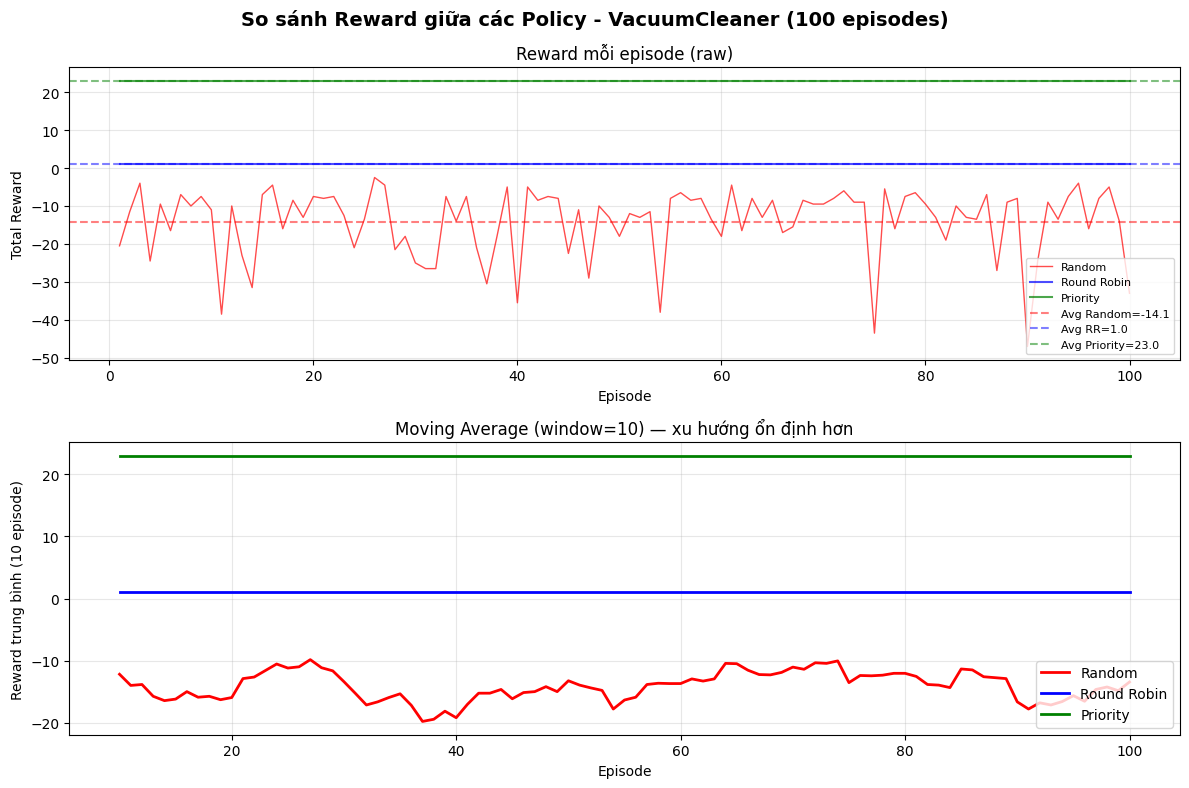

Đã lưu biểu đồ: reward_comparison.png


In [17]:
def plot_rewards(rewards_random, rewards_roundrobin, rewards_priority):
    """
    Vẽ biểu đồ so sánh reward của 3 policy qua 100 episode.
    """
    episodes = list(range(1, 101))  # [1, 2, 3, ..., 100]
    
    # --- Tạo figure với 2 subplot ---
    # Subplot 1: Reward từng episode (raw)
    # Subplot 2: Reward trung bình tích lũy (moving average) — dễ thấy xu hướng hơn
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle("So sánh Reward giữa các Policy - VacuumCleaner (100 episodes)", 
                 fontsize=14, fontweight='bold')
    
    # ===== SUBPLOT 1: Reward thô từng episode =====
    ax1.plot(episodes, rewards_random,     label="Random",      color="red",   alpha=0.7, linewidth=1)
    ax1.plot(episodes, rewards_roundrobin, label="Round Robin", color="blue",  alpha=0.7, linewidth=1.5)
    ax1.plot(episodes, rewards_priority,   label="Priority",    color="green", alpha=0.7, linewidth=1.5)
    
    # Thêm đường trung bình (dashed) để dễ đọc hơn
    ax1.axhline(y=np.mean(rewards_random),     color="red",   linestyle="--", alpha=0.5, label=f"Avg Random={np.mean(rewards_random):.1f}")
    ax1.axhline(y=np.mean(rewards_roundrobin), color="blue",  linestyle="--", alpha=0.5, label=f"Avg RR={np.mean(rewards_roundrobin):.1f}")
    ax1.axhline(y=np.mean(rewards_priority),   color="green", linestyle="--", alpha=0.5, label=f"Avg Priority={np.mean(rewards_priority):.1f}")
    
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Total Reward")
    ax1.set_title("Reward mỗi episode (raw)")
    ax1.legend(loc="lower right", fontsize=8)
    ax1.grid(True, alpha=0.3)  # Lưới mờ để dễ đọc
    
    # ===== SUBPLOT 2: Moving average (trung bình trượt) =====
    # Tại sao dùng moving average?
    # Raw reward có thể dao động nhiều — moving average làm mịn đường để
    # thấy rõ xu hướng học hỏi/ổn định của mỗi policy
    window = 10  # Lấy trung bình 10 episode liên tiếp
    
    def moving_avg(data, w):
        # np.convolve: tính tổng trượt, 'valid' bỏ phần biên không đủ w điểm
        return np.convolve(data, np.ones(w)/w, mode='valid')
    
    ma_episodes = list(range(window, 101))  # Episode bắt đầu từ window
    
    ax2.plot(ma_episodes, moving_avg(rewards_random, window),
             label="Random", color="red", linewidth=2)
    ax2.plot(ma_episodes, moving_avg(rewards_roundrobin, window),
             label="Round Robin", color="blue", linewidth=2)
    ax2.plot(ma_episodes, moving_avg(rewards_priority, window),
             label="Priority", color="green", linewidth=2)
    
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Reward trung bình (10 episode)")
    ax2.set_title(f"Moving Average (window={window}) — xu hướng ổn định hơn")
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()  # Tự điều chỉnh khoảng cách giữa các subplot
    plt.savefig("reward_comparison.png", dpi=150, bbox_inches='tight')  # Lưu file
    plt.show()
    print("Đã lưu biểu đồ: reward_comparison.png")

# Gọi hàm vẽ
plot_rewards(rewards_random, rewards_roundrobin, rewards_priority)

In [18]:
def analyze_policies(rewards_random, rewards_roundrobin, rewards_priority):
    """
    In bảng thống kê và đưa ra nhận xét định lượng.
    """
    print("\n" + "="*60)
    print("BẢNG THỐNG KÊ 100 EPISODES")
    print("="*60)
    print(f"{'Policy':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Thành công':>12}")
    print("-"*60)
    
    for name, rewards in [("Random", rewards_random),
                           ("Round Robin", rewards_roundrobin),
                           ("Priority", rewards_priority)]:
        mean = np.mean(rewards)
        std  = np.std(rewards)
        mn   = min(rewards)
        mx   = max(rewards)
        # "Thành công" = số episode có reward > 0 (không va chướng ngại vật)
        success = sum(1 for r in rewards if r > 0)
        print(f"{name:<15} {mean:>8.2f} {std:>8.2f} {mn:>8.1f} {mx:>8.1f} {success:>10}/100")
    
    print("="*60)
    
    # Xác định policy tốt nhất
    best = max([("Random", np.mean(rewards_random)),
                ("Round Robin", np.mean(rewards_roundrobin)),
                ("Priority", np.mean(rewards_priority))],
               key=lambda x: x[1])
    print(f"\n→ Policy tốt nhất: {best[0]} (mean reward = {best[1]:.2f})")

analyze_policies(rewards_random, rewards_roundrobin, rewards_priority)


BẢNG THỐNG KÊ 100 EPISODES
Policy              Mean      Std      Min      Max   Thành công
------------------------------------------------------------
Random            -14.09     9.15    -47.0     -2.5          0/100
Round Robin         1.00     0.00      1.0      1.0        100/100
Priority           23.00     0.00     23.0     23.0        100/100

→ Policy tốt nhất: Priority (mean reward = 23.00)


In [ ]:
def save(...):
    pass

Evaluation and Analysis

## Part 3: Load Balancing Problem

In [34]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is not None: 
                  self.remaining_time -= 1
            
            
             # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

                  if self.remaining_time == 0: 
                        completed_task = self.current_task
                        self.current_task = None

                        if self.queue: 
                              self.current_task = self.queue.popleft()
                              self.remaining_time = self.current_task.processing_time

           


            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None: 
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True

            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if len(self.queue) < self.queue_capacity: 
                  self.queue.append(task)
                  return True

            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [35]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            self.action_space = gym.spaces.Discrete(n_servers)

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(
                        tuple(
                              gym.spaces.Dict({
                              "remaining_time": gym.spaces.Box(
                                    low=0, high=100, shape=(1,), dtype=np.float32
                              ),
                              "queue_length": gym.spaces.Box(
                                    low=0, high=queue_capacity, shape=(1,), dtype=np.float32
                              ),
                              })
                              for _ in range(n_servers)
                        )
                  ),
                  "time": gym.spaces.Box(low=0, high=np.inf, shape=(1,), dtype=np.float32),
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(
                  task_id=self.next_task_id,
                  processing_time=self.rng.randint(1, 5)
            )
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()


            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers: 
                  completed = server.run_one_step()
                  if completed is not None:
                        self.tasks_completed.add(completed.task_id)
                        reward += 2 



            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            selected_server = self.servers[action]
            accepted = selected_server.add_task(new_task)

            if accepted: 
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else: 
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            for server in self.servers: 
                  reward -= 0.5 * server.queue_length()


            

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = dropped   / total_created if total_created > 0 else 0.0
            
            completion_rate  = completed / accepted      if accepted      > 0 else 0.0


            
            return {
                  # Some example info fields: time, dropped tasks, dop_rate, etc.
                  "time":            self.time,
                  "total_created":   total_created,
                  "accepted":        accepted,
                  "dropped":         dropped,
                  "completed":       completed,
                  "drop_rate":       round(drop_rate, 3),
                  "completion_rate": round(completion_rate, 3),
                  "total_reward":    self.total_reward,

            }

In [36]:
rr_counter = 0   # biến global để round robin nhớ vị trí

def load_balancing_policy(option="random", env=None, obs=None):
      """Simple baseline policy."""

      global rr_counter

      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE 

      elif option == "round_robin": 
            action = rr_counter % env.n_servers
            rr_counter += 1     
            return action

      elif option == "greedy": 
            min_queue = float("inf")
            best_server = 0

            for i, server_obs in enumerate(obs["servers"]):
                  q = server_obs["queue_length"]
                  if q < min_queue:
                        min_queue = q
                        best_server = i

            return best_server

      elif option == "epsilon_greedy":
            epsilon = 0.1   

            if random.random() < epsilon:
                  # Explore: chọn ngẫu nhiên
                  return env.action_space.sample()
            else:
                  # Exploit: dùng greedy
                  min_queue = float("inf")
                  best_server = 0

                  for i, server_obs in enumerate(obs["servers"]):
                        q = server_obs["queue_length"]
                        if q < min_queue:
                              min_queue = q
                              best_server = i

                  return best_server

      
         
      raise ValueError(f"Unsupported policy option: {option}")

In [45]:
import csv
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      metrics_log = []  # Lưu metrics mỗi step

      print(f"{'Step':>5} | {'Action':>6} | {'Reward':>8} | {'Drop Rate':>10} | {'Completed':>10} | {'Dropped':>8}")
      print("-" * 60)


      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="random", env=env, obs = obs)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            # In ra màn hình mỗi step
            print(f"{step+1:>5} | {action:>6} | {reward:>8.2f} | "
                  f"{info['drop_rate']:>10.1%} | {info['completed']:>10} | {info['dropped']:>8}")

            # Lưu vào log
            metrics_log.append({
                  "step":         step + 1,
                  "action":       action,
                  "reward":       round(reward, 2),
                  "total_reward": round(info["total_reward"], 2),
                  "drop_rate":    info["drop_rate"],
                  "completed":    info["completed"],
                  "dropped":      info["dropped"],
            })



      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      # Lưu CSV
      with open("metrics_main.csv", "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=metrics_log[0].keys())
            writer.writeheader()
            writer.writerows(metrics_log)

      # In tổng kết
      print("\n=== TỔNG KẾT ===")
      print(f"Total reward : {info['total_reward']:.2f}")
      print(f"Drop rate    : {info['drop_rate']:.1%}")
      print(f"Completed    : {info['completed']} tasks")
      print(f"Dropped      : {info['dropped']} tasks")
      print("Đã lưu: metrics_main.csv")

 Step | Action |   Reward |  Drop Rate |  Completed |  Dropped
------------------------------------------------------------
    1 |      1 |     0.50 |       0.0% |          0 |        0
    2 |      1 |     2.50 |       0.0% |          1 |        0
    3 |      2 |     2.50 |       0.0% |          2 |        0
    4 |      0 |     0.50 |       0.0% |          2 |        0
    5 |      2 |     0.00 |       0.0% |          2 |        0
    6 |      0 |     4.50 |       0.0% |          4 |        0
    7 |      1 |     0.50 |       0.0% |          4 |        0
    8 |      2 |     6.50 |       0.0% |          7 |        0
    9 |      0 |     0.50 |       0.0% |          7 |        0
   10 |      2 |     2.00 |       0.0% |          8 |        0
   11 |      1 |     0.00 |       0.0% |          8 |        0
   12 |      0 |     0.00 |       0.0% |          8 |        0
   13 |      2 |     4.00 |       0.0% |         10 |        0
   14 |      2 |    -0.50 |       0.0% |         10 |    

In [54]:
import csv

def run_simulation(policy_option, n_steps=100, seed=42):
    """
    Chạy n_steps steps với 1 policy.
    Trả về: (danh sách reward mỗi step, danh sách metrics mỗi step)
    """
    global rr_counter
    rr_counter = 0   # reset Round Robin counter mỗi lần chạy mới

    env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=seed)
    obs, info = env.reset()

    rewards_per_step = []
    metrics_log = []

    for step_i in range(n_steps):
        # Chọn action — truyền cả obs vào để Greedy/Epsilon-Greedy dùng được
        action = load_balancing_policy(option=policy_option, env=env, obs=obs)

        obs, reward, terminated, truncated, info = env.step(action)

        rewards_per_step.append(reward)
        metrics_log.append({
            "step":         step_i + 1,
            "policy":       policy_option,
            "action":       action,
            "reward":       round(reward, 2),
            "total_reward": round(info["total_reward"], 2),
            "drop_rate":    info["drop_rate"],
            "completed":    info["completed"],
            "dropped":      info["dropped"],
        })

    # Lưu CSV
    filename = f"metrics_{policy_option}.csv"
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=metrics_log[0].keys())
        writer.writeheader()
        writer.writerows(metrics_log)

    print(f"[{policy_option}] Xong! "
          f"Total reward={info['total_reward']:.1f} | "
          f"Drop rate={info['drop_rate']:.1%} | "
          f"Completed={info['completed']} | "
          f"Dropped={info['dropped']} | "
          f"Saved: {filename}")

    return rewards_per_step, metrics_log


# =============================================
# Chạy tất cả 4 policy
# =============================================
print("Chạy 100 steps cho từng policy...\n")
r_random,  log_random  = run_simulation("random",         n_steps=100)
r_rr,      log_rr      = run_simulation("round_robin",    n_steps=100)
r_greedy,  log_greedy  = run_simulation("greedy",         n_steps=100)
r_eps,     log_eps     = run_simulation("epsilon_greedy", n_steps=100)

Chạy 100 steps cho từng policy...

[random] Xong! Total reward=19.0 | Drop rate=17.0% | Completed=78 | Dropped=17 | Saved: metrics_random.csv
[round_robin] Xong! Total reward=152.0 | Drop rate=1.0% | Completed=93 | Dropped=1 | Saved: metrics_round_robin.csv
[greedy] Xong! Total reward=154.5 | Drop rate=0.0% | Completed=95 | Dropped=0 | Saved: metrics_greedy.csv
[epsilon_greedy] Xong! Total reward=155.0 | Drop rate=0.0% | Completed=95 | Dropped=0 | Saved: metrics_epsilon_greedy.csv


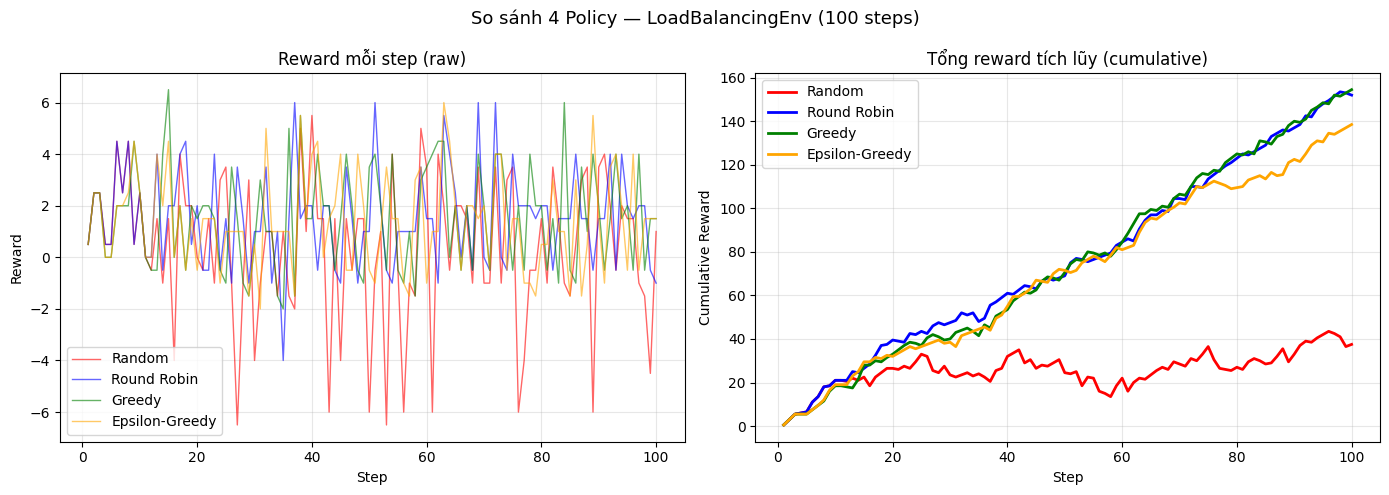

Đã lưu: lb_policy_comparison.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_lb_comparison(r_random, r_rr, r_greedy, r_eps):
    steps = list(range(1, 101))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("So sánh 4 Policy — LoadBalancingEnv (100 steps)", fontsize=13)

    colors = ["red", "blue", "green", "orange"]
    labels = ["Random", "Round Robin", "Greedy", "Epsilon-Greedy"]
    rewards = [r_random, r_rr, r_greedy, r_eps]

    # Subplot 1: reward từng step
    for r, c, l in zip(rewards, colors, labels):
        axes[0].plot(steps, r, color=c, alpha=0.6, label=l, linewidth=1)
    axes[0].set_title("Reward mỗi step (raw)")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Reward")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: cumulative reward (tổng tích lũy)
    # Tại sao dùng cumulative?
    # → Cho thấy policy nào "kiếm được nhiều reward hơn theo thời gian"
    # → Đường dốc lên nhanh = policy tốt
    for r, c, l in zip(rewards, colors, labels):
        axes[1].plot(steps, np.cumsum(r), color=c, label=l, linewidth=2)
    axes[1].set_title("Tổng reward tích lũy (cumulative)")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Cumulative Reward")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("lb_policy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu: lb_policy_comparison.png")

plot_lb_comparison(r_random, r_rr, r_greedy, r_eps)

In [42]:
def analyze_lb_policies(logs):
    """
    In bảng so sánh các chỉ số quan trọng của từng policy.
    logs: dict {policy_name: metrics_log}
    """
    print("\n" + "="*75)
    print("BẢNG THỐNG KÊ LOAD BALANCING (100 STEPS)")
    print("="*75)
    print(f"{'Policy':<18} {'Total Reward':>13} {'Drop Rate':>10} {'Completed':>10} {'Dropped':>8}")
    print("-"*75)

    for name, log in logs.items():
        last = log[-1]   # lấy metrics ở step cuối cùng
        print(f"{name:<18} {last['total_reward']:>13.1f} "
              f"{last['drop_rate']:>10.1%} "
              f"{last['completed']:>10} "
              f"{last['dropped']:>8}")

    print("="*75)

analyze_lb_policies({
    "Random":         log_random,
    "Round Robin":    log_rr,
    "Greedy":         log_greedy,
    "Epsilon-Greedy": log_eps,
})


BẢNG THỐNG KÊ LOAD BALANCING (100 STEPS)
Policy              Total Reward  Drop Rate  Completed  Dropped
---------------------------------------------------------------------------
Random                      37.5      13.0%         82       13
Round Robin                152.0       1.0%         93        1
Greedy                     154.5       0.0%         95        0
Epsilon-Greedy             138.5       0.0%         95        0


In [ ]:
def save_metrics(...):
     # Placeholder for a function to save metrics
     pass

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Part 2,3 of Lab01 - Introduction to Python, Gymnasium and Formulating RL Problem.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

Suggested additional practice resources: https://gymnasium.farama.org/introduction/create_custom_env/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
